# Top Occupations Over Time — Share of Active Individuals

Same shape as **Fig. 2 of Laouenan et al. (2022)** "A cross-verified database of notable people, 3500BC–2018AD" (Sci. Data 9:290): a stacked area chart showing the *share of active individuals per year*, broken down by occupation.

**Definition of "active"** — for each year *y* a person is counted if
`floruit_period_start ≤ y ≤ floruit_period_end` (the project's age-30-to-60 impact window, truncated by death; see `claude/instructions.md`).

**Time axis** — for the World scope we apply the same log transformation as in the paper, `x = −log₁₀(ref_year − year)`, so recent centuries take up the bulk of the chart and deep history compresses to the left. For Roman Empire / Tang Dynasty the spans are short (a few centuries) so we keep linear time.

Three scopes:

- **World** — all individuals with a floruit period (log time, 500 BCE – 2018 CE)
- **Roman Empire** — exact match `;Roman Empire;` (linear time, 200 BCE – 499 CE)
- **Tang Dynasty** — exact match `;Tang Dynasty;` (linear time, 600 – 999 CE)

In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Figure style — large readable text per claude/instructions.md
FIGSIZE = (16, 7.5)
DPI = 130
FONT_HEADER = 26   # polity / scope name centered above the figure (plain black)
FONT_LABEL = 18    # x-axis label
FONT_TICK = 15     # tick labels
FONT_LEGEND = 13   # legend entries

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_HEADER,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

## Setup

In [2]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt
DB = DB_PATH
conn = duckdb.connect(DB, read_only=True)


## Load individuals with occupations and impact dates

We join `individuals` with `individuals_impact_date` and parse the impact year
from the date string, keeping only rows that have a non-empty occupation field.

In [3]:
query = """
    SELECT
        i.wikidata_id,
        i.occupations_en,
        id.floruit_period_start,
        id.floruit_period_end
    FROM individuals i
    JOIN individuals_floruit_period id ON i.wikidata_id = id.wikidata_id
    WHERE i.occupations_en IS NOT NULL AND i.occupations_en != ''
      AND id.floruit_period_start IS NOT NULL
      AND id.floruit_period_end   IS NOT NULL
"""

df = conn.execute(query).pl()
print(f"Loaded {len(df):,} individuals with occupations and a full floruit period")

Loaded 7,448,923 individuals with occupations and a full floruit period


In [4]:
print(f"Loaded {len(df):,} individuals with occupations and impact dates")
df.head(20)

Loaded 7,448,923 individuals with occupations and impact dates


wikidata_id,occupations_en,floruit_period_start,floruit_period_end
str,str,i64,i64
"""Q105595948""","""university teacher; scholar of…",1974,1999
"""Q105595959""","""literary scholar""",1997,2022
"""Q105595973""","""philologist; university teache…",1989,2014
"""Q105596""","""ruler""",1160,1185
"""Q10559614""","""mathematician; computer scient…",1980,2014
…,…,…,…
"""Q10559719""","""politician""",1983,2008
"""Q105597217""","""chemist""",1925,1950
"""Q10559729""","""painter""",1507,1532


## Explode semicolon-separated occupations into individual rows

Each individual may list multiple occupations separated by `; `.
We split these into separate rows so every occupation is counted independently.

In [5]:
df_exploded = (
    df
    .with_columns(
        pl.col('occupations_en').str.split('; ').alias('occupation_list')
    )
    .explode('occupation_list')
    .rename({'occupation_list': 'occupation'})
    .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
)

print(f"Total occupation entries: {len(df_exploded):,}")

Total occupation entries: 10,763,913


## Load polity-specific data: Roman Empire and Tang Dynasty

`polity_name` in `individuals_cliopatria` is a `;`-separated list when an individual sits in several polities.
We use `';' || polity_name || ';'` and match `';Roman Empire;'` / `';Tang Dynasty;'` to get **exact** polity matches — this excludes "Holy Roman Empire" (the `Roman Empire` boundary token never appears between two semicolons in such rows).

In [6]:
polity_query = """
    SELECT
        ic.wikidata_id,
        i.occupations_en,
        ic.floruit_period_start,
        ic.floruit_period_end,
        ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE (
            ';' || ic.polity_name || ';' LIKE '%;Roman Empire;%'
         OR ';' || ic.polity_name || ';' LIKE '%;Tang Dynasty;%'
          )
      AND i.occupations_en IS NOT NULL AND i.occupations_en != ''
      AND ic.floruit_period_start IS NOT NULL
      AND ic.floruit_period_end   IS NOT NULL
"""

df_polities = conn.execute(polity_query).pl()

# Exact-match boundary so 'Holy Roman Empire' is excluded.
df_roman = df_polities.filter(
    (pl.lit(';') + pl.col('polity_name') + pl.lit(';'))
    .str.contains(';Roman Empire;', literal=True)
)
df_tang = df_polities.filter(
    (pl.lit(';') + pl.col('polity_name') + pl.lit(';'))
    .str.contains(';Tang Dynasty;', literal=True)
)

print(f"Roman Empire individuals with occupations: {len(df_roman):,}")
print(f"Tang Dynasty individuals with occupations: {len(df_tang):,}")

Roman Empire individuals with occupations: 3,708
Tang Dynasty individuals with occupations: 1,989


In [7]:
print("Roman Empire sample:")
display(df_roman.head(10))
print("\nTang Dynasty sample:")
display(df_tang.head(10))

Roman Empire sample:


wikidata_id,occupations_en,floruit_period_start,floruit_period_end,polity_name
str,str,i32,i32,str
"""Q12285134""","""politician""",101,200,"""Roman Empire"""
"""Q12285138""","""politician""",80,105,"""Roman Empire"""
"""Q12285139""","""politician""",1,100,"""Roman Empire"""
"""Q12285140""","""politician""",101,200,"""Roman Empire"""
"""Q12285141""","""politician""",1,100,"""Roman Empire"""
"""Q12285143""","""military leader""",225,225,"""Roman Empire"""
"""Q12285144""","""politician""",1,100,"""Roman Empire"""
"""Q12285145""","""politician""",101,200,"""Roman Empire"""
"""Q12285146""","""politician""",101,200,"""Roman Empire"""



Tang Dynasty sample:


wikidata_id,occupations_en,floruit_period_start,floruit_period_end,polity_name
str,str,i32,i32,str
"""Q10478011""","""writer; poet""",858,881,"""Tang Dynasty"""
"""Q10513389""","""military personnel""",709,734,"""Tang Dynasty"""
"""Q10513441""","""military personnel""",804,829,"""Tang Dynasty"""
"""Q10513979""","""military personnel""",704,729,"""Tang Dynasty"""
"""Q10516361""","""politician""",808,833,"""Tang Dynasty"""
"""Q10516472""","""writer; poet; politician""",855,880,"""Tang Dynasty"""
"""Q10526010""","""writer; poet""",852,877,"""Tang Dynasty"""
"""Q10535353""","""poet""",723,748,"""Tang Dynasty"""
"""Q10538415""","""writer; poet; official""",748,772,"""Tang Dynasty"""


## Explode polity occupations

Same `; `-split logic as for the world dataframe, applied to each polity cohort.

In [8]:
def explode_occupations(df_pol):
    return (
        df_pol
        .with_columns(
            pl.col('occupations_en').str.split('; ').alias('occupation_list')
        )
        .explode('occupation_list')
        .rename({'occupation_list': 'occupation'})
        .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
    )

df_roman_exp = explode_occupations(df_roman)
df_tang_exp = explode_occupations(df_tang)

print(f"Roman Empire occupation entries: {len(df_roman_exp):,}")
print(f"Tang Dynasty occupation entries: {len(df_tang_exp):,}")

Roman Empire occupation entries: 5,313
Tang Dynasty occupation entries: 2,577


## Helpers

- `top_occupations_per_century(df, range, k, century_size)` — top-K occupations within **each century**, then unioned across centuries (gives a richer set, ~20-ish, instead of a single global top-10).
- `active_per_year(df, top, range)` — per-year, per-occupation count of individuals whose floruit period covers that year (sweep-line cumulative-sum, O(N + Y)).
- `plot_share_area(...)` — stacked area chart of within-year shares; `log_time=True` applies `x = −log₁₀(ref_year − year)` (after Laouenan et al. 2022 Fig. 2). The polity / scope **name is centered above the chart in plain black**, no chart title, no y-axis label (per `claude/instructions.md` time-series rule).

In [9]:
import numpy as np


def top_occupations_per_century(df_exp, date_range, k_per_century=10,
                                max_total=20, century_size=100):
    """Top-K occupations within each century-bucket, unioned across centuries,
    then truncated to the `max_total` most prominent overall.

    Pipeline: rank each century's occupations by count, keep top K per
    century, union, then keep at most `max_total` by total count across
    the full date range. Returned in descending total-count order so the
    legend reads top-down.
    """
    lo, hi = date_range
    d = (df_exp
         .filter(pl.col('floruit_period_start').is_not_null()
                 & pl.col('floruit_period_start').is_between(lo, hi))
         .with_columns(((pl.col('floruit_period_start') // century_size)
                        * century_size).alias('century')))

    counts = d.group_by(['century', 'occupation']).agg(pl.len().alias('n'))
    ranked = counts.with_columns(
        pl.col('n').rank(method='ordinal', descending=True).over('century').alias('rk')
    )
    keep = ranked.filter(pl.col('rk') <= k_per_century)

    summary = (keep.group_by('occupation')
                   .agg(pl.col('n').sum().alias('total'),
                        pl.col('rk').min().alias('best_rk'))
                   .sort(['total', 'best_rk'], descending=[True, False])
                   .head(max_total))
    return summary['occupation'].to_list()


def active_per_year(df_exp, top_occ, year_range):
    """Per-year, per-occupation count of individuals whose floruit period covers year y.

    Active rule: floruit_period_start ≤ y ≤ floruit_period_end (project's
    age-30-to-60 impact window, truncated by death). Sweep-line cumulative
    sum: O(N + Y).
    Returns: years (np.array), occ_order (list), matrix (dict[occ → np.array]).
    """
    yr_lo, yr_hi = year_range
    df = (df_exp
          .filter(pl.col('floruit_period_start').is_not_null()
                  & pl.col('floruit_period_end').is_not_null())
          .with_columns(
              pl.when(pl.col('occupation').is_in(top_occ))
                .then(pl.col('occupation'))
                .otherwise(pl.lit('Other')).alias('occ_grp'))
          .with_columns(
              pl.col('floruit_period_start').clip(yr_lo, yr_hi).alias('s'),
              pl.col('floruit_period_end').clip(yr_lo, yr_hi).alias('e'))
          .filter(pl.col('s') <= pl.col('e')))

    occ_order = list(top_occ) + ['Other']
    years = np.arange(yr_lo, yr_hi + 1)
    matrix = {}
    for occ in occ_order:
        sub = df.filter(pl.col('occ_grp') == occ).select(['s', 'e'])
        deltas = np.zeros(len(years) + 1, dtype=np.int64)
        if len(sub) > 0:
            s_idx = sub['s'].to_numpy() - yr_lo
            e_idx = sub['e'].to_numpy() - yr_lo
            np.add.at(deltas, s_idx, 1)
            np.add.at(deltas, e_idx + 1, -1)
        matrix[occ] = np.cumsum(deltas[:-1])
    return years, occ_order, matrix


def build_shared_palette(occupation_lists):
    """Single deterministic colour map shared across every figure.
    Same occupation → same colour everywhere. 'Other' is a soft grey.
    """
    seen = []
    for lst in occupation_lists:
        for occ in lst:
            if occ not in seen:
                seen.append(occ)
    base = (list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)
            + list(plt.cm.tab20c.colors))
    cmap = {occ: base[i % len(base)] for i, occ in enumerate(seen)}
    cmap['Other'] = (0.82, 0.82, 0.82)
    return cmap


def _fmt_year(y):
    y = int(round(y))
    return f'{abs(y)} BCE' if y < 0 else f'{y}'


def plot_share_area(years, occ_order, matrix, color_map, scope_name,
                    log_time=True, ref_year=2020, tick_years=None,
                    smooth_window=11):
    """Stacked-area share chart, after Laouenan et al. (2022) Fig. 2.

    No title, no y-axis label (time-series rule). The scope name is
    centered above the figure in plain black, large font.
    """
    years = np.asarray(years, dtype=float)
    counts = np.stack([matrix[o].astype(float) for o in occ_order])

    if smooth_window and smooth_window > 1:
        k = int(smooth_window)
        kernel = np.ones(k) / k
        counts = np.stack([np.convolve(c, kernel, mode='same') for c in counts])

    totals = counts.sum(axis=0)
    valid = totals > 0
    shares = np.where(valid, counts / np.where(valid, totals, 1.0), 0.0)

    if log_time:
        keep = (years < ref_year) & valid
        if not keep.any():
            raise ValueError("No years with data and < ref_year")
        x = -np.log10(ref_year - years[keep])
        Y = shares[:, keep]
        if tick_years is None:
            candidates = (-3000, -1000, -500, -200, 0, 500, 1000, 1500,
                          1700, 1800, 1900, 1950, 2000)
            tick_years = [y for y in candidates if years.min() <= y < ref_year]
        tick_x = [-np.log10(ref_year - y) for y in tick_years]
        xlabel = f'year (log time, ref={ref_year})'
    else:
        keep = valid
        x = years[keep]
        Y = shares[:, keep]
        if tick_years is None:
            tick_years = list(np.linspace(years.min(), years.max(), 8)
                              .round(0).astype(int))
        tick_x = list(tick_years)
        xlabel = 'year'

    fig, ax = plt.subplots()
    colors = [color_map.get(o, '#aaaaaa') for o in occ_order]
    ax.stackplot(x, Y, labels=occ_order, colors=colors,
                 edgecolor='white', linewidth=0.2, alpha=0.95)

    ax.set_xticks(tick_x)
    ax.set_xticklabels([_fmt_year(y) for y in tick_years], rotation=30, ha='right')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, 1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')                      # time-series → no y-axis label
    ax.tick_params(axis='both', length=4)

    # Polity / scope name centered above the figure, plain black, large font.
    fig.suptitle(scope_name, fontsize=FONT_HEADER, color='black',
                 fontweight='normal', y=0.98)

    # Reverse legend order so dominant (bottom-of-stack) occupations appear at top.
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              frameon=False, loc='upper left',
              bbox_to_anchor=(1.01, 1.0), borderaxespad=0,
              handlelength=1.2, handleheight=1.0, labelspacing=0.4)

    ax.grid(True, alpha=0.18, ls='--')
    fig.subplots_adjust(left=0.06, right=0.78, top=0.91, bottom=0.14)
    plt.show()

## Top occupations + shared colour map

Per-scope occupation set = **top-10 within each century**, then unioned across centuries (so era-specific occupations like *presbyter* or *association football player* survive). The colour map is built from the union across all three scopes — every occupation keeps the **same colour in every figure** so the eye can track it.

In [10]:
# Per-scope ranges, then top occupations: top-10 within each century, unioned, capped at 20.
WORLD_RANGE = (-500, 2018)
ROMAN_RANGE = (-200, 499)
TANG_RANGE  = (600, 999)
K_PER_CENTURY = 10
MAX_TOTAL = 20

world_top = top_occupations_per_century(df_exploded,  WORLD_RANGE, K_PER_CENTURY, MAX_TOTAL)
roman_top = top_occupations_per_century(df_roman_exp, ROMAN_RANGE, K_PER_CENTURY, MAX_TOTAL)
tang_top  = top_occupations_per_century(df_tang_exp,  TANG_RANGE,  K_PER_CENTURY, MAX_TOTAL)

# Shared palette — same occupation → same colour across every figure.
SHARED_COLORS = build_shared_palette([world_top, roman_top, tang_top])

print(f"World ({len(world_top)}): {world_top}")
print(f"Roman ({len(roman_top)}): {roman_top}")
print(f"Tang  ({len(tang_top)}): {tang_top}")
print(f"Shared palette: {len(SHARED_COLORS)-1} unique occupations + 'Other'")

World (20): ['researcher', 'politician', 'writer', 'university teacher', 'actor', 'association football player', 'painter', 'journalist', 'poet', 'historian', 'basketball player', 'film director', 'military personnel', 'singer', 'Catholic priest', 'physician', 'lawyer', 'teacher', 'architect', 'Catholic bishop']
Roman (18): ['politician', 'military personnel', 'writer', 'Catholic priest', 'presbyter', 'philosopher', 'poet', 'military officer', 'rabbi', 'historian', 'Catholic bishop', 'monk', 'priest', 'soldier', 'runner', 'mintmaster', 'orator', 'epigrammatist']
Tang  (16): ['poet', 'politician', 'military personnel', 'writer', 'calligrapher', 'painter', 'Buddhist monk', 'military leader', 'official', 'historian', 'military officer', 'aristocrat', 'bureaucrat', 'economist', 'monarch', 'ruler']
Shared palette: 40 unique occupations + 'Other'


## World

Year range: **500 BCE – 2018 CE**, log-transformed time axis (`x = −log₁₀(2020 − year)`).

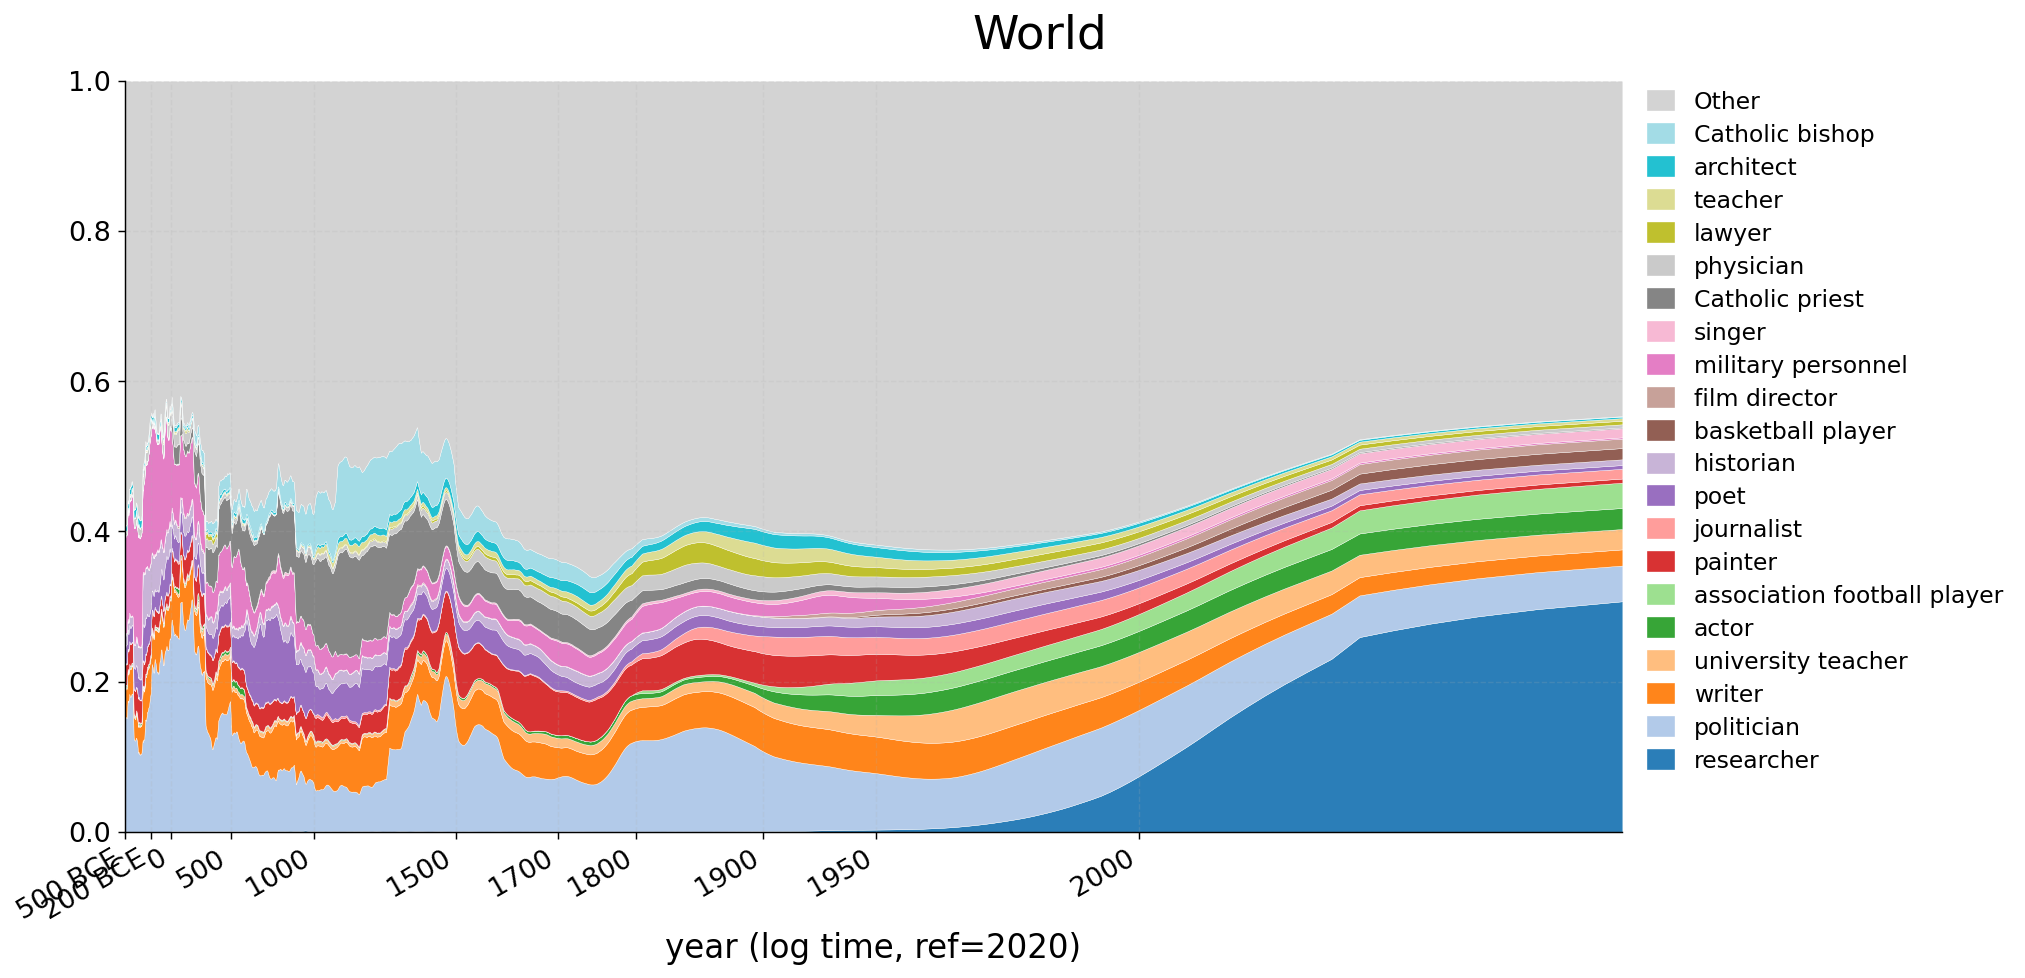

In [11]:
world_years, world_occ, world_mat = active_per_year(df_exploded, world_top, WORLD_RANGE)

plot_share_area(
    world_years, world_occ, world_mat, SHARED_COLORS,
    scope_name='World',
    log_time=True, ref_year=2020,
    smooth_window=11,
)

## Roman Empire

Year range: **200 BCE – 499 CE**. Linear time, since the span is only a few centuries.

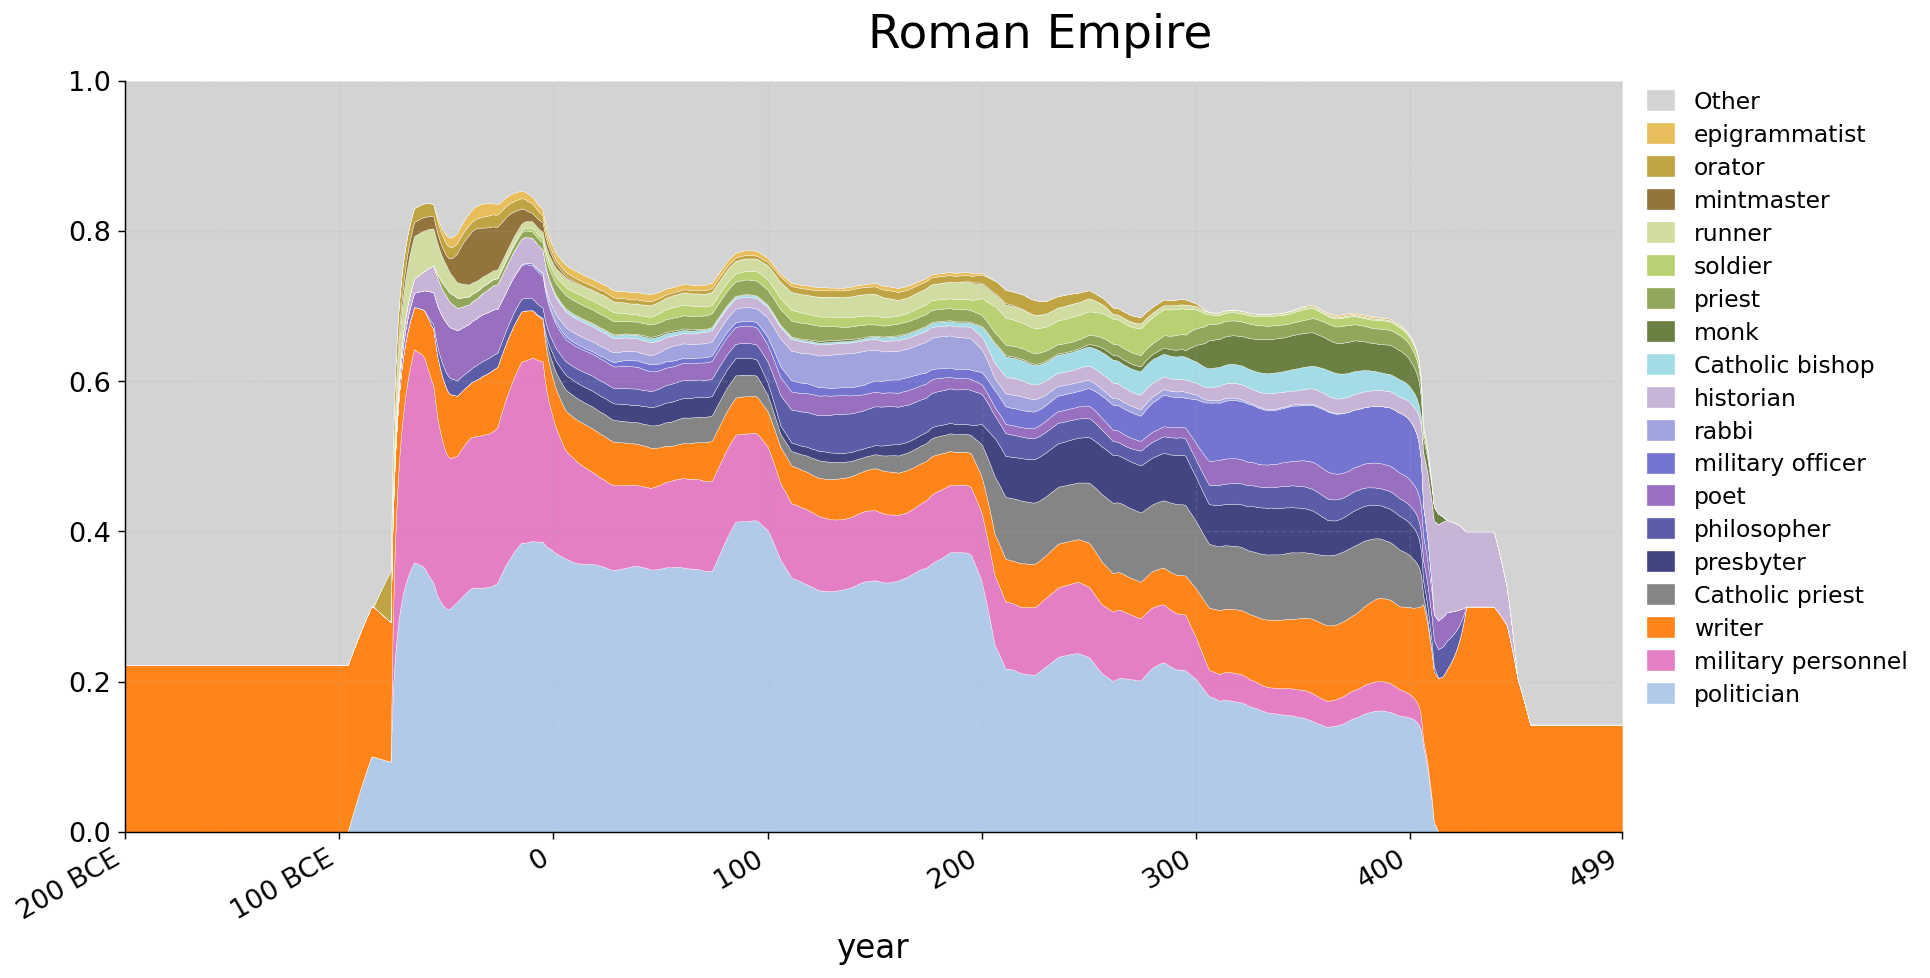

In [12]:
roman_years, roman_occ, roman_mat = active_per_year(df_roman_exp, roman_top, ROMAN_RANGE)

plot_share_area(
    roman_years, roman_occ, roman_mat, SHARED_COLORS,
    scope_name='Roman Empire',
    log_time=False,
    tick_years=[-200, -100, 0, 100, 200, 300, 400, 499],
    smooth_window=11,
)

## Tang Dynasty

Year range: **600 – 999 CE** (Tang itself: 618–907). Linear time.

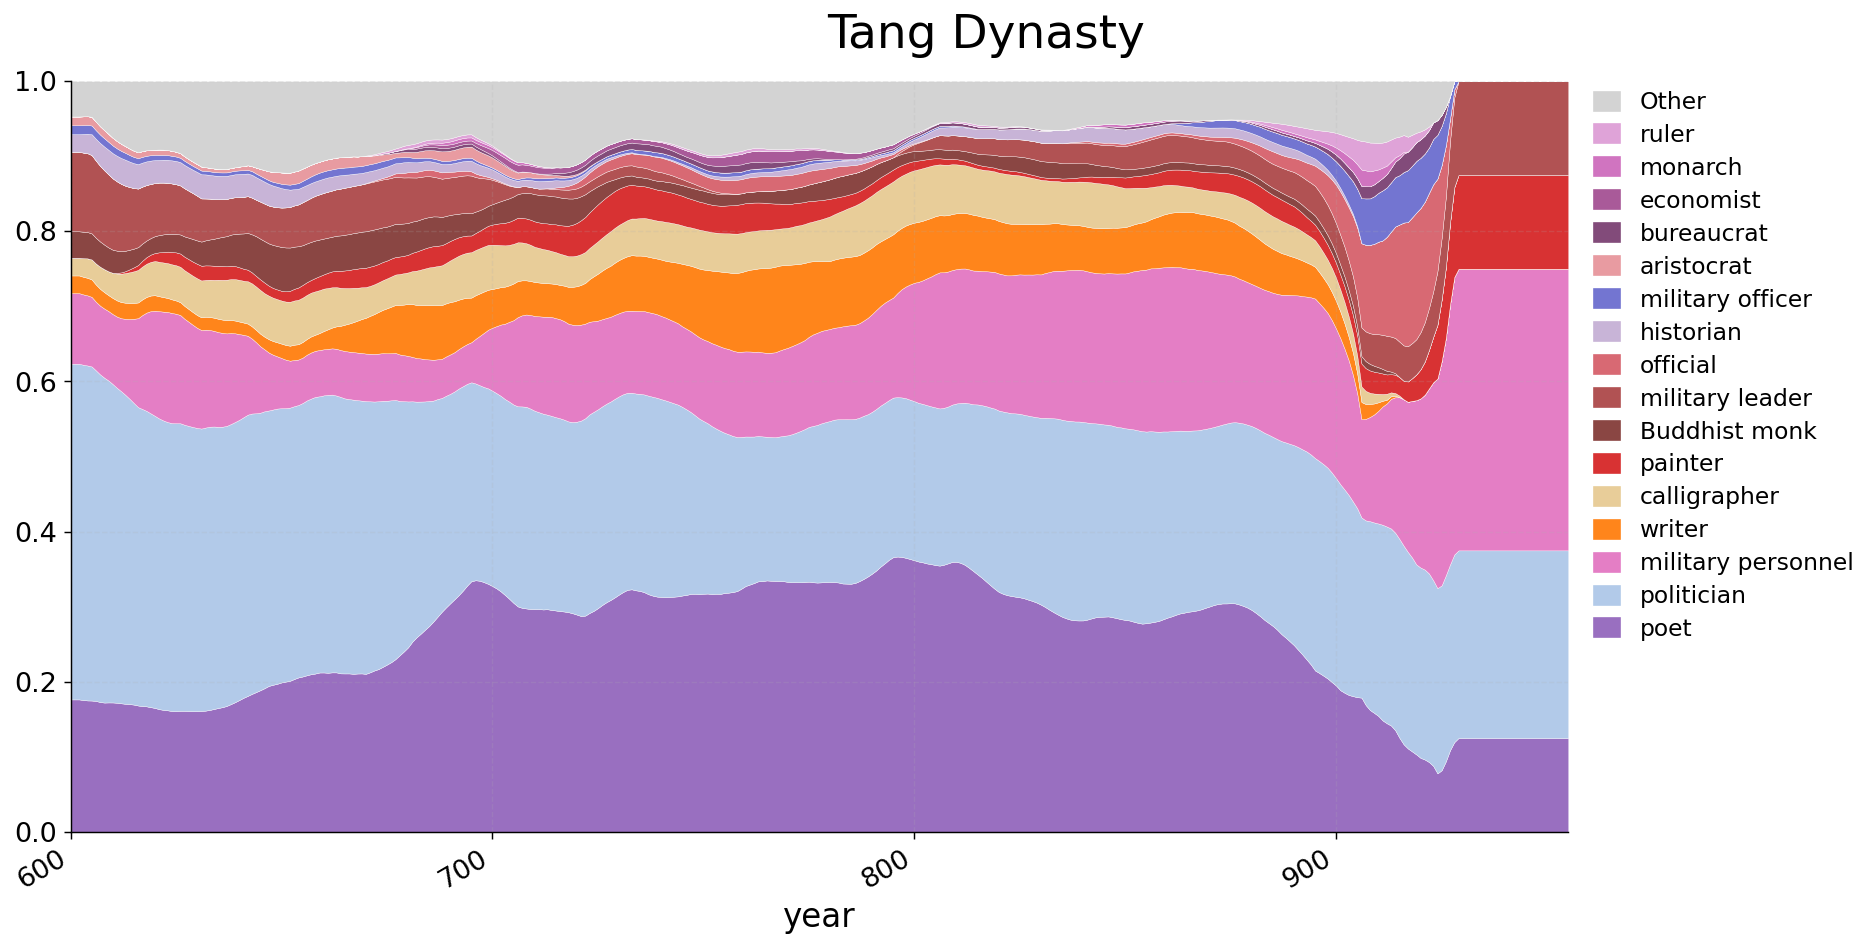

In [13]:
tang_years, tang_occ, tang_mat = active_per_year(df_tang_exp, tang_top, TANG_RANGE)

plot_share_area(
    tang_years, tang_occ, tang_mat, SHARED_COLORS,
    scope_name='Tang Dynasty',
    log_time=False,
    tick_years=[600, 700, 800, 900, 999],
    smooth_window=11,
)

### Number of unique occupations in the database

In [14]:
n_unique_occ = df_exploded['occupation'].n_unique()
n_unique_roman = df_roman_exp['occupation'].n_unique()
n_unique_tang = df_tang_exp['occupation'].n_unique()
print(f"Unique occupations in the database (with floruit dates): {n_unique_occ:,}")
print(f"Unique occupations attested in Roman Empire cohort:      {n_unique_roman:,}")
print(f"Unique occupations attested in Tang Dynasty cohort:      {n_unique_tang:,}")

Unique occupations in the database (with floruit dates): 16,102
Unique occupations attested in Roman Empire cohort:      352
Unique occupations attested in Tang Dynasty cohort:      83


## Clean up

In [15]:
conn.close()